# Customer Behaviour

## Business Context:
The dataset contains purchase records for an electric retailer, dating September 2023 to September 2024. The electronic products that the business offer are smartphones, laptops, tables, and smartwatches.
The main objective of retailer is to undertand their customer purchasing behaviour for strategic purposes such as cutsomer retentin and improve sales. By conducting this analysis the managment could identify patterns that could be useful for strategising.

## Data Content:
The dataset include 20000 transactions throughout the period ranging from September 2023 to September 2024. Each row represent single transcation with feature such as customer demographics, payment methods, shipping type, product type and other features that enables the analysis of sales trends, customer preferences and business perfomance.

Data set is sourced from: https://www.kaggle.com/datasets/cameronseamons/electronic-sales-sep2023-sep2024
![alt text](image.png)



Github https://github.com/siziphiwe734/M504D_Assignment_Siziphiwe

In [2]:
#Importing neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Data

In [ ]:
df = pd.read_csv ('Electronic_sales_Sep2023-Sep2024.csv')
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [4]:
#Understanding the structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  str    
 3   Loyalty Member     20000 non-null  str    
 4   Product Type       20000 non-null  str    
 5   SKU                20000 non-null  str    
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  str    
 8   Payment Method     20000 non-null  str    
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  str    
 13  Shipping Type      20000 non-null  str    
 14  Add-ons Purchased  15132 non-null  str    
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4), str(9)
m

Purchase date is currently importing as a string. This will need to be corrected under data cleaning section.

In [5]:
#Checking missing values for each column
df.isnull().sum()

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

The data set contains null values on 'Gender' and 'Add-ons Purchased' columns. This is not a clean dataset and it requires cleaning before working on it.

In [ ]:
#Getting view of the categories to potential identify unsual or incorrect entries 
Categories_Columns = ['Gender', 'Loyalty Member', 'Product Type', 'SKU','Order Status', 'Payment Method', 'Shipping Type', 'Add-ons Purchased']
for col in Categories_Columns: 
    print('Column:', col)
    print('Unique_values:', df[col].unique())
    print() #for spacing


Column: Gender
Unique_values: <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Column: Loyalty Member
Unique_values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: Product Type
Unique_values: <StringArray>
['Smartphone', 'Tablet', 'Laptop', 'Smartwatch', 'Headphones']
Length: 5, dtype: str

Column: SKU
Unique_values: <StringArray>
['SKU1004', 'SKU1002', 'SKU1005', 'SKU1001', 'SKU1003',  'LTP123',  'SMP234',
  'TBL345',  'HDP456',  'SWT567']
Length: 10, dtype: str

Column: Order Status
Unique_values: <StringArray>
['Cancelled', 'Completed']
Length: 2, dtype: str

Column: Payment Method
Unique_values: <StringArray>
['Credit Card', 'Paypal', 'Cash', 'Debit Card', 'Bank Transfer', 'PayPal']
Length: 6, dtype: str

Column: Shipping Type
Unique_values: <StringArray>
['Standard', 'Overnight', 'Express', 'Same Day', 'Expedited']
Length: 5, dtype: str

Column: Add-ons Purchased
Unique_values: <StringArray>
[                          'Accessory,Accessory,Accessory',
      

In [7]:
#Add-ons Purchased needs more studying for cleaning purposes
df['Add-ons Purchased'].unique()

<StringArray>
[                          'Accessory,Accessory,Accessory',
                                            'Impulse Item',
                                                       nan,
                               'Impulse Item,Impulse Item',
                                               'Accessory',
                                  'Impulse Item,Accessory',
                     'Extended Warranty,Extended Warranty',
                     'Impulse Item,Accessory,Impulse Item',
                             'Accessory,Extended Warranty',
        'Extended Warranty,Impulse Item,Extended Warranty',
                        'Accessory,Impulse Item,Accessory',
                          'Impulse Item,Extended Warranty',
                'Impulse Item,Accessory,Extended Warranty',
                          'Extended Warranty,Impulse Item',
                                     'Accessory,Accessory',
                                       'Extended Warranty',
                          

##Data Cleaning & Preprocessing


In [8]:
#Converting Purchase Date to datetime format
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

Converted to datetime format for the purpose of this assessment.

In [9]:
#Filling missing values for Gender column
df['Gender'] = df['Gender'].fillna('Unkown')

I didn't want to assume gender as it would be also against the current society norms.

In [29]:
#Filling missing values for Purchase Date column
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

In [31]:
#To check if the code applied above ran succefully
df[['Add-ons Purchased', 'Gender']].isnull().sum()

Add-ons Purchased    0
Gender               0
dtype: int64

In [12]:
#Removing repeated categories for each row
#Ref[1]
df['Add-ons Purchased'] = df['Add-ons Purchased'].apply(
    lambda x: ','.join(sorted(set([i.strip() for i in str(x).split(',')] )))
)
#apply - go through each row
#lambda - what to do to each row
#join - back into one clean column
#sorted - sort categories
#str(x).split(',') - spliting each category


The 'Add-ons Purchased' column contained repeated categories for each transaction. For this assessment, i removed the repeatations so that each add on category can appear once pre transanction.

In [13]:
#To check if the code applied above ran succefully
df.tail()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,nan,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,nan,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Accessory,Extended Warranty,Impulse Item",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Accessory,Extended Warranty",101.34
19999,19998,27,Unkown,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,2024-01-29,Expedited,nan,0.00


In [14]:
#fix Paypal to PayPal
df['Payment Method']= df['Payment Method'].replace('Paypal','PayPal')

In [15]:
#To check if the code applied above ran succefully
df['Payment Method'].unique()

<StringArray>
['Credit Card', 'PayPal', 'Cash', 'Debit Card', 'Bank Transfer']
Length: 5, dtype: str

# Exploratory Data Analysis

## Which product generate highest revenue?
- This assist management make informed decisions regarding product focus and resource allocation for example inventory allocation, makerting focus, supplier arrangements etc.

In [16]:
df.groupby('Product Type')['Total Price'].sum().sort_values(ascending=False)

Product Type
Smartphone    21516754.69
Smartwatch    14036273.06
Laptop        12296239.97
Tablet        11712000.41
Headphones     4041400.24
Name: Total Price, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

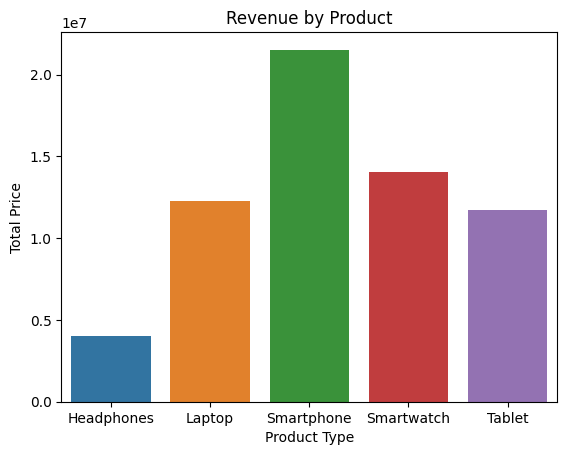

In [17]:
Revenue_product = df.groupby('Product Type')['Total Price'].sum().reset_index()
sns.barplot(x= 'Product Type', y= 'Total Price', hue= 'Product Type', data=Revenue_product)
plt.title ('Revenue by Product')
plt.xlabel('Product Type')
plt.ylabel('Total Price')
plt.show

In [18]:
df.groupby('Product Type')['Quantity'].sum().sort_values(ascending= False)

Product Type
Smartphone    32660
Tablet        22653
Smartwatch    21631
Laptop        21584
Headphones    11183
Name: Quantity, dtype: int64

In [19]:
#checking if the revenue could be influenced by the product price
df.groupby('Product Type')['Total Price'].agg(['min', 'max']).reset_index()

,Product Type,min,max
0,Headphones,361.18,4130.2
1,Laptop,463.96,6743.2
2,Smartphone,20.75,11396.8
3,Smartwatch,459.50,8448.3
4,Tablet,247.03,7864.1


As shown by the analysis abaove Smartphone comes up to be the product that generates highest revenue compared to other electronic products and it doesn't seem like the revenue is influenced by the product pricing. This could be influenced by strong demand. These results indicate that managemenet needs to consider prioritising inventory availability, advertisement and supplier partnership. 
Potentially also create package deals to increase sales for slow moving product for example a combination of Smartphones and headsets.

## Do loyalty members contribute more to the revenue than non-members?
- This could assist management in identifying ooportunities of driving up sales through loyalty membership.

In [20]:
df.groupby('Loyalty Member')['Total Price'].sum()

Loyalty Member
No     49976751.24
Yes    13625917.13
Name: Total Price, dtype: float64

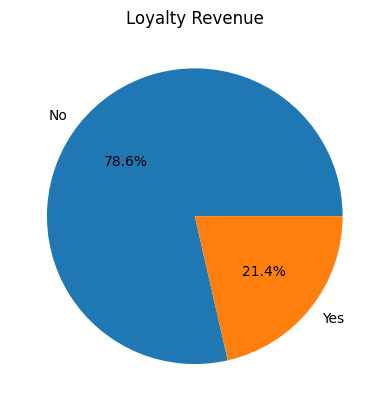

In [21]:
Revenue_loyalty = df.groupby('Loyalty Member')['Total Price'].sum()
Revenue_loyalty.plot.pie(title= 'Loyalty Revenue', autopct = '%1.1f%%')
plt.ylabel(None)
plt.show()

According to the analysis above loyalty members contribute only 21.4% to the revenue of the business. This suggest that management are not using the loyalty member to it's full protential as a value-add. If customers don't see any value out of loyalty membership then they won't sign up for it. Management could create value-add such as discounts, cut a deal with 3rd parties for example with an insurance company for loyalty members to pay less premiums if they choose to insure their devices with them. 

## Which period shows the highest purchased activity
This assist can assist management to identify opportunities of improvement in periods that has less activities.


In [22]:
#Converting datetime to period [2]
df['YearMonth'] = df['Purchase Date'].dt.to_period('M') 
df.groupby('YearMonth')['Quantity'].sum()

YearMonth
2023-09     1023
2023-10     5027
2023-11     4310
2023-12     4352
2024-01    11185
2024-02     9882
2024-03    10697
2024-04    10748
2024-05    11230
2024-06    10903
2024-07    10948
2024-08    11102
2024-09     8304
Freq: M, Name: Quantity, dtype: int64

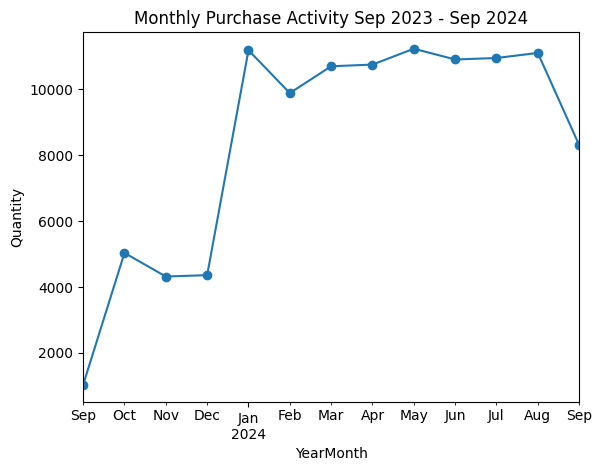

In [23]:
Monthly_actvity = df.groupby('YearMonth')['Quantity'].sum()
Monthly_actvity.plot(kind= 'line', marker='o')
plt.title ('Monthly Purchase Activity Sep 2023 - Sep 2024')
plt.xlabel('YearMonth')
plt.ylabel('Quantity')
plt.show()

According to the analysis above most months almost generate the same level of sales, slight different spike in January which might mean there was a seasonal demand. 
The analysis also indicate that demand decline from September to December which management can look into the reasons as why it is such and find way of increasing sales during that period.

## Which payment method is mostly used?
This could assist management to identify opporutinities for cost management by negotiating a deal with a service provider or drive sales by encouraging a certain gender to pay using a specifc method.

In [24]:
#Most used method
df.groupby(['Payment Method', 'Gender']).size()

Payment Method  Gender
Bank Transfer   Female    1592
                Male      1778
                Unkown       1
Cash            Female    1287
                Male      1205
Credit Card     Female    2871
                Male      2997
Debit Card      Female    1232
                Male      1239
PayPal          Female    2853
                Male      2945
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

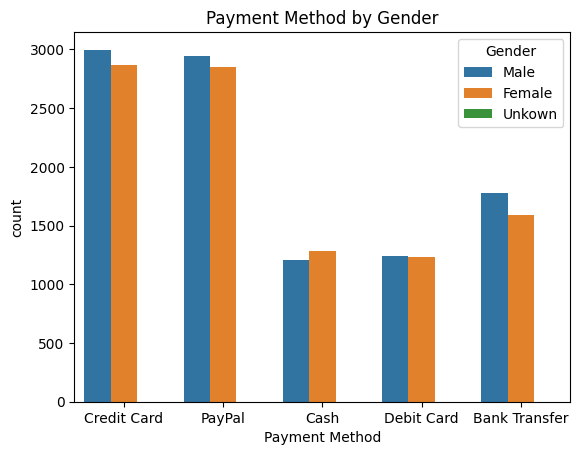

In [25]:
df.groupby(['Payment Method', 'Gender']).size()
sns.countplot(x= 'Payment Method', hue= 'Gender', data=df)
plt.title ('Payment Method by Gender')
plt.show

According to the analysis Credit card and PayPal are the most frequently used payment methods and also associated with high fees. Management could negotiate a better fee rate with providers or encourange the use of lower fee payment method such as Debit card or Bank transfer. It is important that they also consider the fact that both these frequently used payment method maybe driving up sales as customers have spending flexibility as purchase can be made without immediate cash.
When it comes gender it's fairly distributed maybe they could influence cost effective paying methods by targeting a certain group and running a sale or offer.


## Is there a relationship between quantity sold and rating?

In [26]:
df.groupby('Product Type')['Quantity'].sum().sort_values(ascending= False)

Product Type
Smartphone    32660
Tablet        22653
Smartwatch    21631
Laptop        21584
Headphones    11183
Name: Quantity, dtype: int64

In [27]:
df.groupby('Product Type')[['Quantity','Rating']].mean()

,Quantity,Rating
Product Type,,
Headphones,5.560915,2.993536
Laptop,5.432671,2.984898
Smartphone,5.463366,3.319003
Smartwatch,5.498475,2.994408
Tablet,5.519737,3.016326


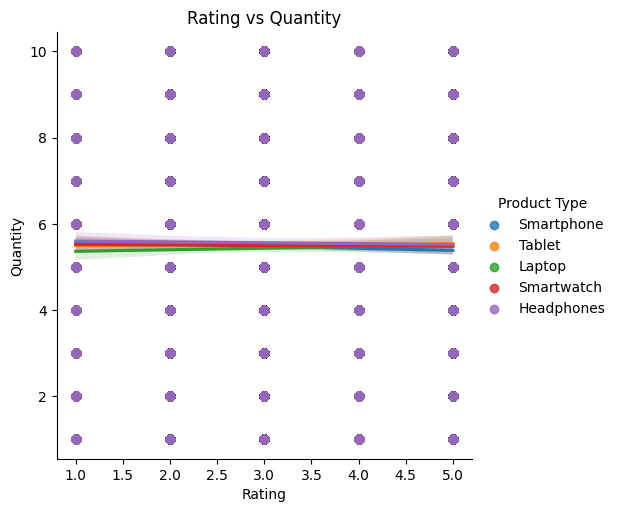

In [28]:
sns.lmplot(x= 'Rating', y= 'Quantity', hue= 'Product Type',  data=df)
plt.title ('Rating vs Quantity')
plt.show()

Even though the product rating is above average according to the analysis there seems to be no relationship between quantity sold and ratings. This could suggest that there are other factors influencing sales such as demand, pricing, marketing etc. 
It is also important for management to consider looking at customer feedback as it could help them find ways of improvement which would result to longterm customer relationship and brand perception.

## Conclusion
The analysis provided insights about the perfomance of the business and customer patterns that the management can use for maximising sales, marketing focus and identify profitable partnerships  with third parties.

## References
www.youtube.com. (n.d.). Matplotlib Tutorial (Part 1): Creating and Customizing Our First Plots. [online] Available at: https://www.youtube.com/watch?v=UO98lJQ3QGI&list=PL-osiE80TeTvipOqomVEeZ1HRrcEvtZB_. Accessed[Form 19/03/2026] whole series

‌


![alt text](image-1.png)